In [4]:
# Cell 1: Import & Setup
import os, time, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
def seed_everything(s=42):
    random.seed(s); os.environ['PYTHONHASHSEED']=str(s)
    np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED); os.makedirs("outputs", exist_ok=True)
print("PyTorch:", torch.__version__)

PyTorch: 2.14.0+cpu


In [5]:
# Cell 2: Load & preprocess dữ liệu nhà (numeric features)
df = pd.read_csv("vietnam_housing_dataset.csv")
df.columns = [c.strip().replace('\ufeff','') for c in df.columns]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = [c for c in num_cols if 'price' in c.lower() or 'gia' in c.lower()]
target_col = target_col[0] if target_col else num_cols[-1]
feat_cols = [c for c in num_cols if c != target_col]

df_c = df[feat_cols + [target_col]].dropna().copy()
q1, q3 = df_c[target_col].quantile(0.05), df_c[target_col].quantile(0.95)
df_c = df_c[(df_c[target_col] >= q1) & (df_c[target_col] <= q3)]

X = df_c[feat_cols].values.astype(np.float32)
y = df_c[target_col].values.reshape(-1,1).astype(np.float32)

X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val_raw, X_te_raw, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED)

sx, sy = StandardScaler(), StandardScaler()
X_tr = sx.fit_transform(X_tr_raw).astype(np.float32)
X_val = sx.transform(X_val_raw).astype(np.float32)
X_te = sx.transform(X_te_raw).astype(np.float32)
y_tr_s = sy.fit_transform(y_tr).astype(np.float32)
y_val_s = sy.transform(y_val).astype(np.float32)
y_te_s = sy.transform(y_te).astype(np.float32)

print(f"Features: {X_tr.shape[1]} | Train/Val/Test: {len(X_tr)}/{len(X_val)}/{len(X_te)}")

train_loader = DataLoader(TensorDataset(
    torch.tensor(X_tr).unsqueeze(1), torch.tensor(y_tr_s)),
    batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(
    torch.tensor(X_val).unsqueeze(1), torch.tensor(y_val_s)),
    batch_size=64, shuffle=False)
X_te_t = torch.tensor(X_te).unsqueeze(1)

Features: 6 | Train/Val/Test: 7658/1641/1641


In [6]:
# Cell 3: Baseline Regressor
class BaselineReg(nn.Module):
    def __init__(self, L):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Flatten(),
            nn.Linear(32 * (L//4), 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x): return self.net(x)

def train_reg(model, tr_loader, val_loader, epochs=40, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    hist = {'train_loss':[], 'val_loss':[]}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tl, n = 0., 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); out = model(xb)
            loss = criterion(out, yb); loss.backward(); opt.step()
            tl += loss.item()*len(yb); n += len(yb)
        model.eval(); vl, vn = 0., 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl += criterion(model(xb), yb).item()*len(yb); vn += len(yb)
        hist['train_loss'].append(tl/n); hist['val_loss'].append(vl/vn)
    return hist, time.time()-t0

seed_everything(SEED)
baseline_reg = BaselineReg(X_tr.shape[1])
hist_base, t_base = train_reg(baseline_reg, train_loader, val_loader, epochs=40)
print(f"Baseline Regressor — {t_base:.2f}s")

Baseline Regressor — 34.50s


In [7]:
# Cell 4: Improved Regressor
class ImprovedReg(nn.Module):
    def __init__(self, L, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

seed_everything(SEED)
improved_reg = ImprovedReg(X_tr.shape[1])
hist_imp, t_imp = train_reg(improved_reg, train_loader, val_loader, epochs=40)
print(f"Improved Regressor — {t_imp:.2f}s")

Improved Regressor — 32.25s


Baseline | MAE=1.2921 | RMSE=1.6105 | R²=0.3001
Improved | MAE=1.3053 | RMSE=1.6087 | R²=0.3016


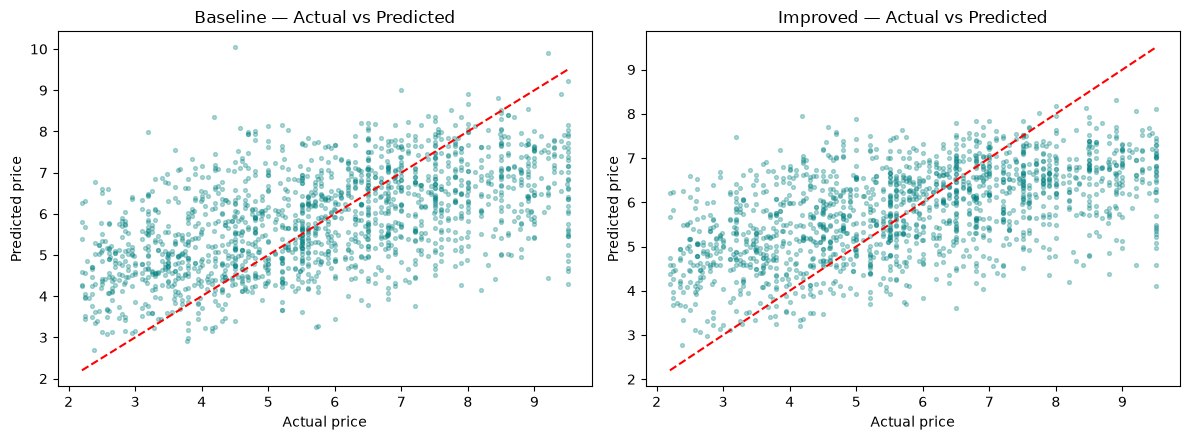

In [8]:
# Cell 5: Evaluate PyTorch models + biểu đồ Actual vs Predicted
def predict_reg(model, X_tensor, device):
    model.eval()
    with torch.no_grad(): return model(X_tensor.to(device)).cpu().numpy()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
y_pred_b = sy.inverse_transform(predict_reg(baseline_reg, X_te_t, device))
y_pred_i = sy.inverse_transform(predict_reg(improved_reg, X_te_t, device))
y_true = sy.inverse_transform(y_te_s)

def metrics(y, yp):
    return (mean_absolute_error(y, yp),
            np.sqrt(mean_squared_error(y, yp)), r2_score(y, yp))

mae_b, rmse_b, r2_b = metrics(y_true, y_pred_b)
mae_i, rmse_i, r2_i = metrics(y_true, y_pred_i)
print(f"Baseline | MAE={mae_b:.4f} | RMSE={rmse_b:.4f} | R²={r2_b:.4f}")
print(f"Improved | MAE={mae_i:.4f} | RMSE={rmse_i:.4f} | R²={r2_i:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, yp, t in zip(axes, [y_pred_b, y_pred_i], ['Baseline','Improved']):
    ax.scatter(y_true, yp, alpha=0.3, s=8, color='teal')
    lo, hi = y_true.min(), y_true.max()
    ax.plot([lo,hi],[lo,hi],'r--', lw=1.5)
    ax.set_title(f"{t} — Actual vs Predicted")
    ax.set_xlabel("Actual price"); ax.set_ylabel("Predicted price")
plt.tight_layout(); plt.savefig("outputs/house_price_scatter.png", dpi=200); plt.show()

In [9]:
# Cell 6: TensorFlow/Keras Regressor
import tensorflow as tf
from tensorflow.keras import layers, models
tf.random.set_seed(SEED)

def build_tf_reg(L):
    m = models.Sequential([
        layers.Input(shape=(L,1)),
        layers.Conv1D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv1D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

X_tr_tf = X_tr[..., None]; X_val_tf = X_val[..., None]; X_te_tf = X_te[..., None]
tf_reg = build_tf_reg(X_tr.shape[1]); tf_reg.summary()
t0 = time.time()
tf_reg.fit(X_tr_tf, y_tr_s, validation_data=(X_val_tf, y_val_s),
           epochs=40, batch_size=64, verbose=0)
t_tf = time.time() - t0
y_pred_tf = sy.inverse_transform(tf_reg.predict(X_te_tf, verbose=0))
mae_tf, rmse_tf, r2_tf = metrics(y_true, y_pred_tf)
print(f"TensorFlow | MAE={mae_tf:.4f} | RMSE={rmse_tf:.4f} | R²={r2_tf:.4f} | {t_tf:.2f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 6, 32)               │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 6, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 6, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 6, 64)               │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 192 (768.00 B)

TensorFlow | MAE=1.3036 | RMSE=1.6349 | R²=0.2787 | 75.23s


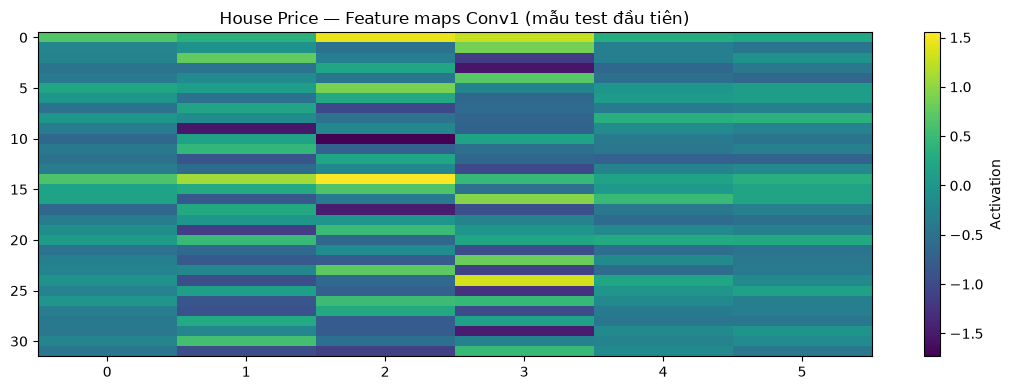

In [10]:
# Cell 7: Feature maps từ Conv1
improved_reg.eval()
with torch.no_grad():
    fm = improved_reg.net[0](X_te_t[0:1]).squeeze(0).cpu().numpy()
plt.figure(figsize=(11, 4))
plt.imshow(fm, aspect='auto', cmap='viridis')
plt.colorbar(label='Activation')
plt.title("House Price — Feature maps Conv1 (mẫu test đầu tiên)")
plt.tight_layout(); plt.savefig("outputs/house_price_feature_maps.png", dpi=200); plt.show()

In [11]:
# Cell 8: Top các mẫu dự đoán sai nhiều nhất (residual analysis)
residuals = np.abs(y_true.ravel() - y_pred_i.ravel())
top_idx = np.argsort(-residuals)[:15]
err_df = pd.DataFrame({
    'idx': top_idx, 'true_price': y_true.ravel()[top_idx],
    'pred_price': y_pred_i.ravel()[top_idx],
    'abs_error': residuals[top_idx]
})
print("TOP HIGH-RESIDUAL SAMPLES:")
print(err_df.to_string(index=False))
err_df.to_csv("outputs/house_price_high_residual.csv", index=False)

TOP HIGH-RESIDUAL SAMPLES:
 idx  true_price  pred_price  abs_error
 473         9.5    4.099663   5.400337
 586         9.5    4.584706   4.915294
1537         9.2    4.583146   4.616854
 170         9.5    4.957651   4.542349
 549         9.5    5.076129   4.423871
1268         8.8    4.380725   4.419275
 409         9.5    5.213068   4.286932
  68         3.2    7.479391   4.279390
 531         9.5    5.275692   4.224308
1022         9.5    5.344481   4.155519
 666         2.5    6.597993   4.097993
1573         9.5    5.405808   4.094192
1630         9.5    5.434775   4.065225
  80         9.0    4.975927   4.024073
 931         2.2    6.218486   4.018486


In [12]:
# Cell 9: Summary
summary = pd.DataFrame([
    {'Framework':'PyTorch Baseline','MAE':mae_b,'RMSE':rmse_b,'R2':r2_b,'Time':t_base},
    {'Framework':'PyTorch Improved','MAE':mae_i,'RMSE':rmse_i,'R2':r2_i,'Time':t_imp},
    {'Framework':'TensorFlow','MAE':mae_tf,'RMSE':rmse_tf,'R2':r2_tf,'Time':t_tf},
])
print(summary.to_string(index=False))
summary.to_csv("outputs/house_price_framework.csv", index=False)

       Framework      MAE     RMSE       R2      Time
PyTorch Baseline 1.292107 1.610460 0.300102 34.503850
PyTorch Improved 1.305277 1.608709 0.301623 32.253031
      TensorFlow 1.303601 1.634902 0.278696 75.231805
